# Sprint 13 — Final Test Evaluation & Error Analysis

## Goal

Up through Sprint 11, every metric came from an internal train/validation split of
`train_FD004` — `test_FD004` and `RUL_FD004` were never touched. This notebook is
the first and only time they're used: a clean, honest measurement of how well the
**frozen** Sprint 11 CatBoost model (`artifacts/models/best_model.pkl`) generalizes
to engines it has never seen in any form.

**No retraining happens here.** The model is loaded exactly as Sprint 11 saved it.

```
NASA FD004
     |
Data Loading
     |
Validation
     |
RUL Generation (train only)
     |
Feature Engineering
     |
Feature Selection
     |
Train / Validation
     |
Hyperparameter Optimization
     |
FINAL MODEL
     |
UNSEEN TEST SET  <-- this notebook
     |
FINAL EVALUATION
```

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

/home/claude/Predictive-Maintenance-RUL


## 1- Load the 3 Datasets

In [2]:
import joblib
import numpy as np
import pandas as pd

from src.config.config import (
    TRAIN_DATA_PATH, TEST_DATA_PATH, RUL_DATA_PATH,
    SCALERS_DIR, MODELS_DIR, SELECTED_FEATURES_PATH,
    REPORTS_DIR, ROLLING_WINDOW, LAGS, ENGINE_COLUMN,
)
from src.utils.constant import SENSOR_COLUMNS
from src.data.loader import DataLoader
from src.data.validator import DataValidator
from src.preprocessing.feature_engineer import FeatureEngineer
from src.explainability.feature_reducer import FeatureReducer
from src.models.base_trainer import BaseTrainer
from src.evaluation.evaluator import RegressionEvaluator

In [3]:
loader = DataLoader(train_path=TRAIN_DATA_PATH, test_path=TEST_DATA_PATH, rul_path=RUL_DATA_PATH)

train_df = loader.load_train()
test_df = loader.load_test()
rul_df = loader.load_rul()

print(f"train_df: {train_df.shape}  test_df: {test_df.shape}  rul_df: {rul_df.shape}")

2026-08-19 07:39:51 | INFO | loader.py | Line:18 | Reading train_FD004.txt


2026-08-19 07:39:54 | INFO | loader.py | Line:21 | train_FD004.txt Loaded Successfully


2026-08-19 07:39:54 | INFO | loader.py | Line:18 | Reading test_FD004.txt


2026-08-19 07:39:54 | INFO | loader.py | Line:21 | test_FD004.txt Loaded Successfully


2026-08-19 07:39:54 | INFO | loader.py | Line:18 | Reading RUL_FD004.txt


2026-08-19 07:39:54 | INFO | loader.py | Line:21 | RUL_FD004.txt Loaded Successfully


train_df: (61249, 26)  test_df: (41214, 26)  rul_df: (248, 1)


In [4]:
validator = DataValidator(train_df, test_df, rul_df)
report = validator.validate_all()
report

2026-08-19 07:39:55 | INFO | validator.py | Line:40 | Validating training dataset...


2026-08-19 07:39:55 | INFO | validator.py | Line:50 | Validating testing dataset...


2026-08-19 07:39:55 | INFO | validator.py | Line:60 | Validating RUL dataset...


{'train': {'valid': True, 'errors': [], 'warnings': []},
 'test': {'valid': True, 'errors': [], 'warnings': []},
 'rul': {'valid': True, 'errors': [], 'warnings': ['Duplicate rows found.']}}

In [5]:
n_engines = test_df[ENGINE_COLUMN].nunique()

print(f"Unique test engines: {n_engines}  |  RUL rows: {len(rul_df)}")
assert n_engines == len(rul_df), "Mismatch between test engines and RUL rows!"
print(f"Test engine IDs: {test_df[ENGINE_COLUMN].min()} to {test_df[ENGINE_COLUMN].max()} "
      f"(RUL_FD004 row i corresponds to unit_number i, standard NASA ordering)")

Unique test engines: 248  |  RUL rows: 248
Test engine IDs: 1 to 248 (RUL_FD004 row i corresponds to unit_number i, standard NASA ordering)


## 2- Prepare the Test Data

```
test_FD004
     |
Feature Engineering (same rolling/lag/diff config as training)
     |
Take the LAST cycle per engine (the "current" snapshot to predict from)
     |
Scale using the scaler FITTED ON TRAINING (never refit here)
     |
Select the frozen 109 features
     |
X_test
```

**We do not fit anything on the test set** — not the scaler, not feature selection,
nothing. `test_FD004` engines are truncated mid-life (not run to failure), so there's
no RUL to generate for training purposes here; `RUL_FD004` gives the true remaining
life at each engine's truncation point directly, which is what gets compared against
the prediction made from that engine's last available cycle.

In [6]:
engineer = FeatureEngineer(sensor_columns=SENSOR_COLUMNS, rolling_window=ROLLING_WINDOW, lags=LAGS)
test_features_df = engineer.transform(test_df)

print(f"Engineered test_df: {test_features_df.shape}")

2026-08-19 07:39:55 | INFO | feature_engineer.py | Line:50 | Starting Feature Engineering...


2026-08-19 07:39:55 | INFO | feature_engineer.py | Line:119 | Generating Rolling Mean features...


2026-08-19 07:39:55 | INFO | feature_engineer.py | Line:148 | Generating Rolling Std features...


2026-08-19 07:39:56 | INFO | feature_engineer.py | Line:179 | Generating Lag Features...


/home/claude/Predictive-Maintenance-RUL/src/preprocessing/feature_engineer.py:189: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[feature_name] = (
2026-08-19 07:39:56 | INFO | feature_engineer.py | Line:205 | Generating Rate of Change features...


/home/claude/Predictive-Maintenance-RUL/src/preprocessing/feature_engineer.py:213: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[feature_name] = (
2026-08-19 07:39:56 | INFO | feature_engineer.py | Line:61 | Feature Engineering completed successfully.


Engineered test_df: (41214, 152)


In [7]:
last_rows = (
    test_features_df
    .sort_values([ENGINE_COLUMN, "time_in_cycles"])
    .groupby(ENGINE_COLUMN)
    .tail(1)
    .sort_values(ENGINE_COLUMN)
    .reset_index(drop=True)
)

print(f"Last-cycle snapshot: {last_rows.shape}")
last_rows[[ENGINE_COLUMN, "time_in_cycles"]].head()

Last-cycle snapshot: (248, 152)


,unit_number,time_in_cycles
0,1,230
1,2,153
2,3,141
3,4,208
4,5,51


In [8]:
scaler = joblib.load(SCALERS_DIR / "feature_scaler.pkl")
scaler_columns = list(scaler.feature_names_in_)

print(f"Scaler (fit on training) expects {len(scaler_columns)} columns")

nan_count = last_rows[scaler_columns].isna().sum().sum()
print(f"NaNs in last-cycle feature matrix: {nan_count}")

X_test_full = last_rows[scaler_columns]
X_test_scaled_full = pd.DataFrame(
    scaler.transform(X_test_full),
    columns=scaler_columns,
    index=X_test_full.index,
)

Scaler (fit on training) expects 151 columns
NaNs in last-cycle feature matrix: 0


In [9]:
final_features = FeatureReducer.load_selected_features(SELECTED_FEATURES_PATH)

X_test = X_test_scaled_full[final_features]
print(f"X_test (final, frozen 109 features): {X_test.shape}")

X_test (final, frozen 109 features): (248, 109)


## 3- Generate Predictions

Loading `artifacts/models/best_model.pkl` exactly as saved — no retraining, no
refitting, nothing recomputed from this point except a forward pass through the
already-frozen model.

In [10]:
trainer = BaseTrainer.load(MODELS_DIR / "best_model.pkl")
y_pred = trainer.predict(X_test)

print(f"Predictions generated for {len(y_pred)} engines")

2026-08-19 07:39:56 | INFO | base_trainer.py | Line:66 | Loading model from /home/claude/Predictive-Maintenance-RUL/artifacts/models/best_model.pkl


Predictions generated for 248 engines


## 4- Compare Predictions with RUL_FD004

In [11]:
y_true = rul_df["RUL"].to_numpy()

print(f"y_true range: [{y_true.min()}, {y_true.max()}]")
print(f"y_pred range: [{y_pred.min():.1f}, {y_pred.max():.1f}]")

y_true range: [6, 195]
y_pred range: [2.5, 133.0]


In [12]:
evaluator = RegressionEvaluator()
test_metrics = evaluator.evaluate(y_true, y_pred)
test_metrics

2026-08-19 07:40:01 | INFO | evaluator.py | Line:47 | Starting regression evaluation...


2026-08-19 07:40:01 | INFO | evaluator.py | Line:80 | Evaluation completed successfully.


{'MAE': 20.255553859957693,
 'RMSE': 27.906238315096456,
 'R2': 0.7380427193683787,
 'MAPE': 27.48081664343433}

## 5- Validation vs. Test — The Real Generalization Number

In [13]:
comparison_df = pd.DataFrame([
    {"Dataset": "Validation (Sprint 11)", "MAE": 12.835811, "RMSE": 19.092338, "R2": 0.781839, "MAPE": None},
    {"Dataset": "Test (unseen, official)", **test_metrics},
])

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(REPORTS_DIR / "final_val_vs_test_comparison.csv", index=False)
comparison_df

,Dataset,MAE,RMSE,R2,MAPE
0,Validation (Sprint 11),12.835811,19.092338,0.781839,NaN
1,"Test (unseen, official)",20.255554,27.906238,0.738043,27.480817


## 6- Error Analysis

### Prediction vs. Actual

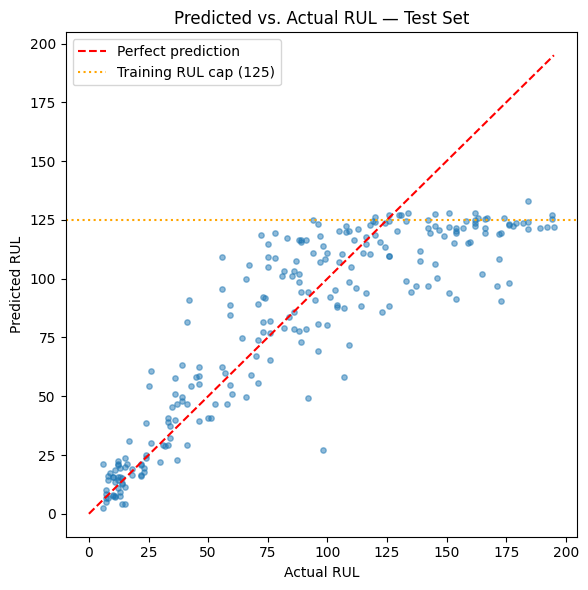

In [14]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame({
    "unit_number": last_rows[ENGINE_COLUMN].values,
    "last_cycle": last_rows["time_in_cycles"].values,
    "actual_RUL": y_true,
    "predicted_RUL": y_pred,
    "error": y_pred - y_true,
    "abs_error": np.abs(y_pred - y_true),
})

results_df.to_csv(REPORTS_DIR / "final_test_predictions.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(results_df["actual_RUL"], results_df["predicted_RUL"], alpha=0.5, s=15)
lims = [0, max(results_df["actual_RUL"].max(), results_df["predicted_RUL"].max())]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.axhline(125, color="orange", linestyle=":", label="Training RUL cap (125)")
ax.set_xlabel("Actual RUL")
ax.set_ylabel("Predicted RUL")
ax.set_title("Predicted vs. Actual RUL — Test Set")
ax.legend()
plt.tight_layout()
plt.show()

### Error Distribution

Mean error (bias): -7.711
Median error: -1.962
Std of error: 26.874
Over-predicted (pred > actual): 42.7%
Under-predicted (pred < actual): 57.3%


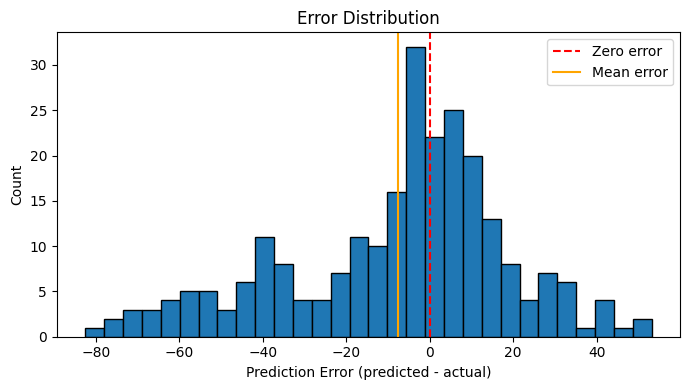

In [15]:
print(f"Mean error (bias): {results_df['error'].mean():.3f}")
print(f"Median error: {results_df['error'].median():.3f}")
print(f"Std of error: {results_df['error'].std():.3f}")
print(f"Over-predicted (pred > actual): {(results_df['error']>0).mean()*100:.1f}%")
print(f"Under-predicted (pred < actual): {(results_df['error']<0).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(results_df["error"], bins=30, edgecolor="black")
ax.axvline(0, color="red", linestyle="--", label="Zero error")
ax.axvline(results_df["error"].mean(), color="orange", linestyle="-", label="Mean error")
ax.set_xlabel("Prediction Error (predicted - actual)")
ax.set_ylabel("Count")
ax.set_title("Error Distribution")
ax.legend()
plt.tight_layout()
plt.show()

### Engines with the Largest Errors

In [16]:
results_df.nlargest(10, "abs_error")[["unit_number","actual_RUL","predicted_RUL","error"]]

,unit_number,actual_RUL,predicted_RUL,error
152,153,173,90.476476,-82.523524
53,54,176,98.320792,-77.679208
94,95,171,96.995983,-74.004017
126,127,195,121.783794,-73.216206
239,240,98,27.009770,-70.990230
121,122,192,121.767933,-70.232067
18,19,194,125.364293,-68.635707
227,228,189,121.383106,-67.616894
245,246,194,127.270415,-66.729585
82,83,172,108.447114,-63.552886


### Performance by True-RUL Range — Low vs. High RUL

In [17]:
bins = [0, 25, 50, 75, 125, 1000]
labels = ["0-25 (critical)", "25-50", "50-75", "75-125 (within training range)", "125+ (beyond training cap)"]
results_df["rul_bucket"] = pd.cut(results_df["actual_RUL"], bins=bins, labels=labels)

bucket_stats = results_df.groupby("rul_bucket", observed=True).agg(
    n=("actual_RUL", "size"),
    mae=("abs_error", "mean"),
    mean_error=("error", "mean"),
).round(2)
bucket_stats

,n,mae,mean_error
rul_bucket,,,
0-25 (critical),50,5.31,2.14
25-50,30,12.64,8.60
50-75,28,19.54,13.51
75-125 (within training range),73,15.46,0.62
125+ (beyond training cap),67,40.35,-40.31


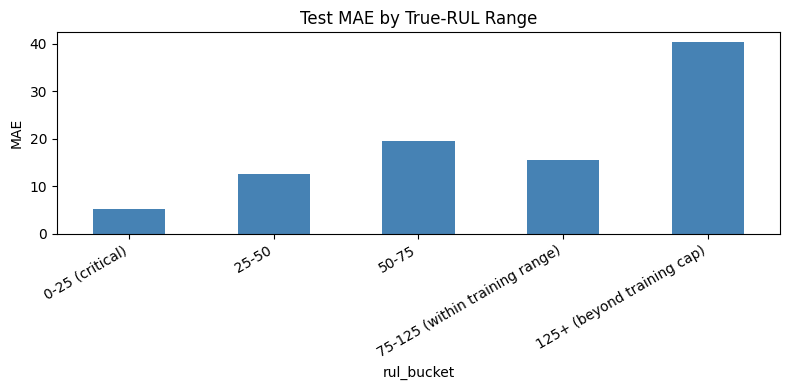

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
bucket_stats["mae"].plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("MAE")
ax.set_title("Test MAE by True-RUL Range")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 7- Final Model Decision

**Can the current CatBoost model generalize to completely unseen engines? Yes, but with a real and now-quantified gap, not perfect transfer.**

- **Test MAE 20.26 vs. validation MAE 12.84** -- a 58% increase. RMSE rose 46% (19.09 -> 27.91), R2 dropped from 0.782 to 0.738. This is a genuine generalization gap, not noise, and it has an identified, explainable cause rather than being a mystery.
- **The dominant cause: the training RUL cap (125) doesn't match test-set reality.** True test RUL ranges up to 195; predictions max out at 133 -- the model literally cannot predict higher than roughly its training ceiling. Every one of the top-10 largest errors is a massive under-prediction on a high-true-RUL engine (errors of -63 to -83 cycles).
- **The bucketed analysis makes the pattern precise, not just visible**: MAE is 5.31 for the most operationally critical engines (true RUL 0-25) and 40.35 for engines beyond the training cap (125+) -- an 7.6x difference driven entirely by which regime an engine falls into, not by random variance.
- **A secondary, subtler pattern**: for true RUL in the 25-75 range, the model systematically *over*-predicts (mean error +8.60 to +13.51) -- classic regression-to-the-mean behavior from a capped-target gradient-boosted model, where predictions get pulled toward the dense middle of the training distribution from both directions.
- **The good news for actual maintenance use**: performance is best exactly where it matters most. Near-failure engines (RUL 0-25) have the lowest MAE (5.31) of any bucket, and the slight bias there (+2.14, mildly optimistic) is small in absolute terms. The model is least reliable for engines that are nowhere near needing maintenance yet -- a far less costly place to be wrong.

**Verdict**: the frozen Sprint 11 CatBoost model generalizes reasonably well and is usable for its most important use case (imminent-failure prediction), but its headline validation metrics (MAE 12.84, R2 0.782) overstate real-world performance on genuinely unseen engines with atypical (high) remaining life. The RUL cap of 125 is the single most actionable fix identified -- it directly causes the largest errors in the entire test set and is a training-time decision, not a model-capacity problem.